<a href="https://colab.research.google.com/github/sanika-boop/CSL701-CS54Machine-Learning-Lab/blob/main/Copy_of_ML_Experiment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name=Sanika Pradip Shirsat
Roll Number=CS54


### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
# Task 1: Load and Understand the Dataset
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Column names
columns = [
"Pregnancies",
"Glucose",
"BloodPressure",
"SkinThickness",
"Insulin",
"BMI",
"DiabetesPedigreeFunction",
"Age",
"Outcome"
]
# Load the dataset
df = pd.read_csv("diabetes (3).csv",
header=0) # Use the first row as header
df.columns = columns # Assign the desired column names
# 1. Print first 5 records
print("First 5 records:")
print(df.head())
# 2. Print dataset shape
print("\nDataset shape:")
print(df.shape)
# 3. Print data types
print("\nData types:")
print(df.dtypes)
# 4. Print descriptive statistics
print("\nDescriptive statistics:")
print(df.describe())

First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape:
(768, 9)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    floa

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Balance:
                  Count  Percentage
Non-Diabetic (0)    500   65.104167
Diabetic (1)        268   34.895833


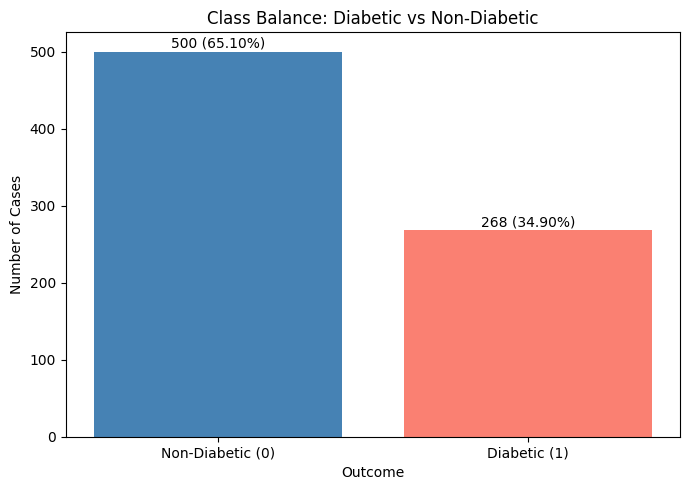

In [8]:
# Calculate absolute counts
class_counts = df["Outcome"].value_counts().sort_index()

# Calculate percentages
class_percentages = df["Outcome"].value_counts(normalize=True).sort_index() * 100

# Display counts and percentages
class_balance = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

# Rename the index for readability
class_balance.index = ["Non-Diabetic (0)", "Diabetic (1)"]

print("Class Balance:")
print(class_balance)

# Bar chart
plt.figure(figsize=(7, 5))

bars = plt.bar(
    class_balance.index,
    class_balance["Count"],
    color=["steelblue", "salmon"]
)

plt.title("Class Balance: Diabetic vs Non-Diabetic")
plt.xlabel("Outcome")
plt.ylabel("Number of Cases")

# Display count and percentage above each bar
for bar, count, percentage in zip(
    bars,
    class_balance["Count"],
    class_balance["Percentage"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count} ({percentage:.2f}%)",
        ha="center"
    )

plt.tight_layout()
plt.show()


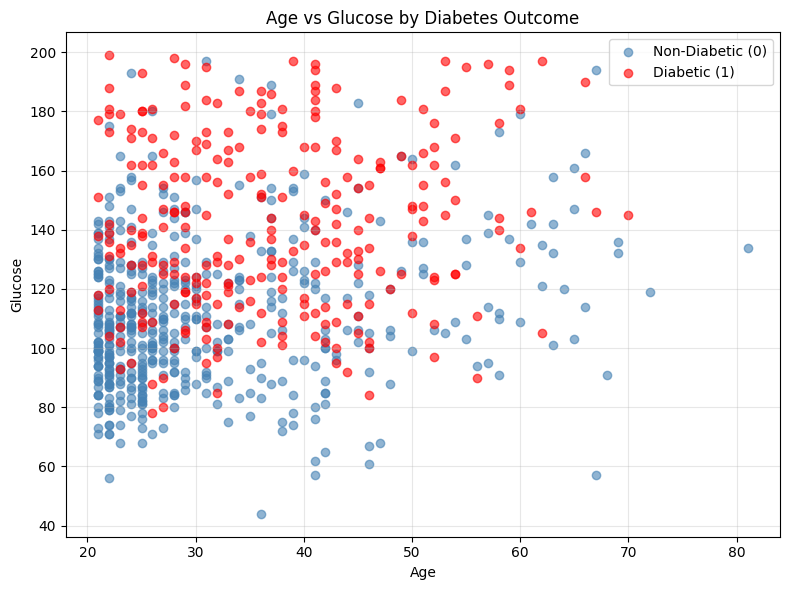

In [9]:
plt.figure(figsize=(8, 6))

# Plot non-diabetic cases
plt.scatter(
    df[df["Outcome"] == 0]["Age"],
    df[df["Outcome"] == 0]["Glucose"],
    color="steelblue",
    alpha=0.6,
    label="Non-Diabetic (0)"
)

# Plot diabetic cases
plt.scatter(
    df[df["Outcome"] == 1]["Age"],
    df[df["Outcome"] == 1]["Glucose"],
    color="red",
    alpha=0.6,
    label="Diabetic (1)"
)

plt.title("Age vs Glucose by Diabetes Outcome")
plt.xlabel("Age")
plt.ylabel("Glucose")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Explanation: Insufficiency of a Simple Linear Decision Boundary

Looking at the scatter plot of 'Age' against 'Glucose', color-coded by 'Outcome', it's evident that the two classes (diabetic and non-diabetic) are not perfectly separable by a straight line or a simple linear boundary. The data points for 'Outcome = 0' (non-diabetic) and 'Outcome = 1' (diabetic) significantly overlap across various ranges of both 'Age' and 'Glucose'.

- There are many instances where individuals with similar 'Age' and 'Glucose' levels fall into different 'Outcome' categories.
- The diabetic (red) points are interspersed within the non-diabetic (blue) points, without a clear region where one class completely dominates.

This overlap suggests that a simple linear classifier would likely misclassify a substantial number of points, leading to poor performance. More complex decision boundaries, potentially non-linear, or models that consider multiple features simultaneously, are required to effectively distinguish between the two classes.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [10]:
# Task 3: Preprocessing and Handling Missing Values

# Features where 0 represents an invalid/missing measurement
invalid_zero_features = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# 1. Count invalid zero values before replacement
print("Number of zero values before replacement:")
print((df[invalid_zero_features] == 0).sum())

# 2. Replace invalid 0 values with NaN
df[invalid_zero_features] = df[invalid_zero_features].replace(0, np.nan)

# Check missing values after replacement
print("\nMissing values after replacing zeros with NaN:")
print(df.isnull().sum())

# 3. Impute missing values using the median
# Median is relatively robust to outliers.
for column in invalid_zero_features:
    df[column] = df[column].fillna(df[column].median())

# Verify that no missing values remain
print("\nMissing values after median imputation:")
print(df.isnull().sum())

# Display the first five records after preprocessing
print("\nFirst five records after preprocessing:")
print(df.head())


Number of zero values before replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values after replacing zeros with NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

First five records after preprocessing:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1         

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [11]:
# Task 4: Stratified Train-Test Splitting

from sklearn.model_selection import train_test_split

# 1. Separate feature matrix X and target vector y
X = df.iloc[:, :8]   # First 8 columns
y = df.iloc[:, 8]    # 9th column (Outcome)

# 2. Perform an 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Display the resulting shapes
print("Training feature set shape:", X_train.shape)
print("Testing feature set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Check class proportions
print("\nOverall class proportions:")
print(y.value_counts(normalize=True))

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))


Training feature set shape: (614, 8)
Testing feature set shape: (154, 8)
Training target shape: (614,)
Testing target shape: (154,)

Overall class proportions:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Training class proportions:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing class proportions:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [21]:
# ============================================================
# TASK 5: CUSTOM BOOTSTRAP SAMPLING FUNCTION
# ============================================================

# Import required libraries
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. Custom Bootstrap Sampling Function
# ------------------------------------------------------------

def get_bootstrap_sample(X, y):
    """
    Generate a bootstrap sample using sampling with replacement.

    Parameters
    ----------
    X : pandas DataFrame
        Feature matrix.

    y : pandas Series
        Target vector.

    Returns
    -------
    X_bootstrap : pandas DataFrame
        Resampled feature matrix.

    y_bootstrap : pandas Series
        Resampled target vector.

    indices : numpy.ndarray
        Original row positions selected during sampling.
    """

    # Number of observations in the training set
    N = len(X)

    # Randomly select N indices WITH replacement
    indices = np.random.choice(
        N,
        size=N,
        replace=True
    )

    # Create bootstrap feature matrix
    X_bootstrap = X.iloc[indices].copy()

    # Create bootstrap target vector
    y_bootstrap = y.iloc[indices].copy()

    return X_bootstrap, y_bootstrap, indices


# ------------------------------------------------------------
# 2. Generate a Bootstrap Sample
# ------------------------------------------------------------

# Set random seed for reproducible results
np.random.seed(42)

X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 3. Check Bootstrap Sample Size
# ------------------------------------------------------------

print("=" * 60)
print("BOOTSTRAP SAMPLE SIZE")
print("=" * 60)

print("Original training set size:", len(X_train))
print("Bootstrap X size:", len(X_bootstrap))
print("Bootstrap y size:", len(y_bootstrap))

print("\nBootstrap sample shapes:")
print("X_bootstrap:", X_bootstrap.shape)
print("y_bootstrap:", y_bootstrap.shape)


# ------------------------------------------------------------
# 4. Verify Duplicate Samples
# ------------------------------------------------------------

# Find unique indices and how many times each was selected
unique_indices, counts = np.unique(
    bootstrap_indices,
    return_counts=True
)

# Find indices that appear more than once
duplicated_indices = unique_indices[counts > 1]

print("\n" + "=" * 60)
print("DUPLICATE SAMPLE CHECK")
print("=" * 60)

print("Number of unique samples:", len(unique_indices))
print("Number of duplicated indices:", len(duplicated_indices))

print("\nSome duplicated indices:")
print(duplicated_indices[:10])

# Show their frequencies
print("\nFrequency of some duplicated indices:")

for index in duplicated_indices[:10]:
    frequency = counts[unique_indices == index][0]
    print("Index", index, "appears", frequency, "times")


# ------------------------------------------------------------
# 5. Find Out-of-Bag (OOB) Samples
# ------------------------------------------------------------

# All possible row positions in the training set
all_indices = set(range(len(X_train)))

# Row positions selected in the bootstrap sample
selected_indices = set(bootstrap_indices)

# OOB = observations that were NOT selected
oob_indices = sorted(
    all_indices - selected_indices
)

print("\n" + "=" * 60)
print("OUT-OF-BAG (OOB) SAMPLE CHECK")
print("=" * 60)

print("Number of OOB samples:", len(oob_indices))

print("\nSome OOB indices:")
print(oob_indices[:10])


# ------------------------------------------------------------
# 6. Create the Actual OOB Dataset
# ------------------------------------------------------------

X_oob = X_train.iloc[oob_indices].copy()
y_oob = y_train.iloc[oob_indices].copy()

print("\nOOB feature matrix shape:", X_oob.shape)
print("OOB target vector shape:", y_oob.shape)


# ------------------------------------------------------------
# 7. Final Verification
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

print(
    "Bootstrap X has correct size:",
    len(X_bootstrap) == len(X_train)
)

print(
    "Bootstrap y has correct size:",
    len(y_bootstrap) == len(y_train)
)

print(
    "Duplicate samples exist:",
    len(duplicated_indices) > 0
)

print(
    "OOB samples exist:",
    len(oob_indices) > 0
)

print(
    "Sampling was performed with replacement:",
    len(unique_indices) < len(bootstrap_indices)
)


BOOTSTRAP SAMPLE SIZE
Original training set size: 614
Bootstrap X size: 614
Bootstrap y size: 614

Bootstrap sample shapes:
X_bootstrap: (614, 8)
y_bootstrap: (614,)

DUPLICATE SAMPLE CHECK
Number of unique samples: 377
Number of duplicated indices: 164

Some duplicated indices:
[ 1  4  8 11 14 20 21 27 32 34]

Frequency of some duplicated indices:
Index 1 appears 3 times
Index 4 appears 3 times
Index 8 appears 2 times
Index 11 appears 2 times
Index 14 appears 2 times
Index 20 appears 2 times
Index 21 appears 2 times
Index 27 appears 2 times
Index 32 appears 2 times
Index 34 appears 2 times

OUT-OF-BAG (OOB) SAMPLE CHECK
Number of OOB samples: 237

Some OOB indices:
[2, 3, 5, 6, 10, 12, 23, 25, 29, 30]

OOB feature matrix shape: (237, 8)
OOB target vector shape: (237,)

FINAL VERIFICATION
Bootstrap X has correct size: True
Bootstrap y has correct size: True
Duplicate samples exist: True
OOB samples exist: True
Sampling was performed with replacement: True


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Task 6: Growing the Ensemble of Base Classifiers

# 1. Initialize an empty list to store the trained models
ensemble_models = []

# Choose the number of bootstrap iterations
B = 50

print(f"Training {B} Decision Trees for the Bagging ensemble...")

# 2. Execute the following steps for B iterations
for i in range(B):
    # Generate a unique bootstrap training dataset
    # Note: The get_bootstrap_sample function now returns X_bootstrap, y_bootstrap, and indices
    X_bootstrap, y_bootstrap, _ = get_bootstrap_sample(X_train, y_train)

    # Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None (fully grown)
    # Using i for random_state provides different random splits for each tree, increasing diversity
    model = DecisionTreeClassifier(max_depth=None, random_state=i)

    # Fit the decision tree on the bootstrapped training subset
    model.fit(X_bootstrap, y_bootstrap)

    # Append the trained model to the ensemble list
    ensemble_models.append(model)

print(f"\nTraining complete. The ensemble now contains {len(ensemble_models)} independently trained decision trees.")

Training 50 Decision Trees for the Bagging ensemble...

Training complete. The ensemble now contains 50 independently trained decision trees.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [26]:
import numpy as np

# Task 7: Implementing Aggregation (Majority Voting) from Scratch

def custom_bagging_predict(ensemble, X_test):
    """
    Aggregates predictions from an ensemble of classifiers using majority voting.

    Args:
        ensemble (list): A list of trained Scikit-learn classifier models.
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.array: Final predictions for X_test based on majority voting.
    """
    # Collect predictions from all base models
    # Each row corresponds to a model's predictions for all X_test samples
    all_predictions = np.array([model.predict(X_test) for model in ensemble])

    # Transpose to get predictions for each sample across all models
    # Shape will be (n_samples, n_estimators)
    all_predictions_transposed = all_predictions.T

    final_predictions = []
    for sample_preds in all_predictions_transposed:
        # Count votes for each class (0 and 1)
        # np.bincount is efficient for non-negative integers
        counts = np.bincount(sample_preds.astype(int))

        # The predicted class is the one with the majority vote.
        # If there's a tie, np.argmax returns the first occurrence (e.g., class 0).
        final_predictions.append(np.argmax(counts))

    return np.array(final_predictions)

print("Custom Bagging Prediction function defined.")

Custom Bagging Prediction function defined.


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [29]:
# Task 8: Single Classifier vs. Bagging Performance Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

# 1. Train a standalone, single DecisionTreeClassifier (fully grown) on the original training data
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)

# 2. Predict the classes for X_test using both models
y_pred_single_tree = single_tree_model.predict(X_test)
y_pred_bagging = custom_bagging_predict(ensemble_models, X_test)

# 3. Construct Confusion Matrix for both models
cm_single_tree = confusion_matrix(y_test, y_pred_single_tree)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("\n--- Single Decision Tree Performance ---")
print("Confusion Matrix:\n", cm_single_tree)
print("Accuracy:", accuracy_score(y_test, y_pred_single_tree))
print("Precision:", precision_score(y_test, y_pred_single_tree))
print("Recall:", recall_score(y_test, y_pred_single_tree))
print("F1-Score:", f1_score(y_test, y_pred_single_tree))

print("\n--- Custom Bagging Ensemble Performance ---")
print("Confusion Matrix:\n", cm_bagging)
print("Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Precision:", precision_score(y_test, y_pred_bagging))
print("Recall:", recall_score(y_test, y_pred_bagging))
print("F1-Score:", f1_score(y_test, y_pred_bagging))


--- Single Decision Tree Performance ---
Confusion Matrix:
 [[87 13]
 [16 38]]
Accuracy: 0.8116883116883117
Precision: 0.7450980392156863
Recall: 0.7037037037037037
F1-Score: 0.7238095238095238

--- Custom Bagging Ensemble Performance ---
Confusion Matrix:
 [[93  7]
 [11 43]]
Accuracy: 0.8831168831168831
Precision: 0.86
Recall: 0.7962962962962963
F1-Score: 0.8269230769230769


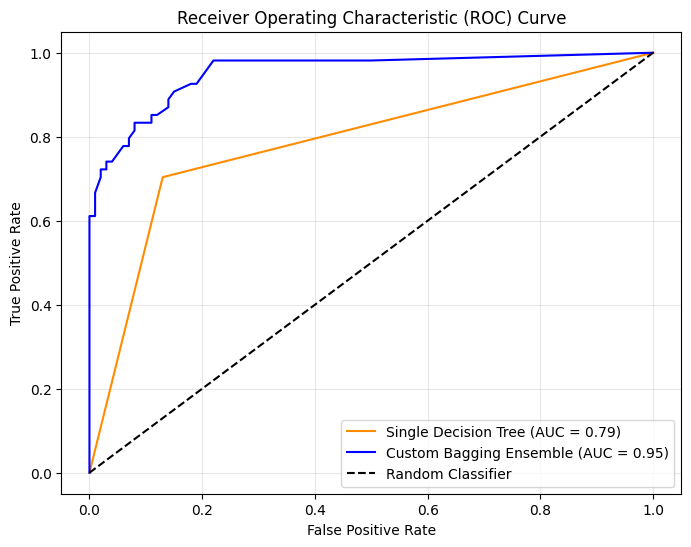


AUC for Single Decision Tree: 0.79
AUC for Custom Bagging Ensemble: 0.95


In [31]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculate predicted class probabilities for the single decision tree
y_prob_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# 2. Calculate predicted class probabilities for the custom Bagging model
# Average the probabilities across all B decision trees
# Ensure predict_proba is called for each model and then averaged
all_ensemble_probs = np.array([model.predict_proba(X_test)[:, 1] for model in ensemble_models])
y_prob_bagging = np.mean(all_ensemble_probs, axis=0)

# Compute ROC curve and AUC for single tree
fpr_single, tpr_single, _ = roc_curve(y_test, y_prob_single_tree)
auc_single = roc_auc_score(y_test, y_prob_single_tree)

# Compute ROC curve and AUC for bagging ensemble
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = roc_auc_score(y_test, y_prob_bagging)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.2f})', color='darkorange')
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging Ensemble (AUC = {auc_bagging:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC for Single Decision Tree: {auc_single:.2f}")
print(f"AUC for Custom Bagging Ensemble: {auc_bagging:.2f}")

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

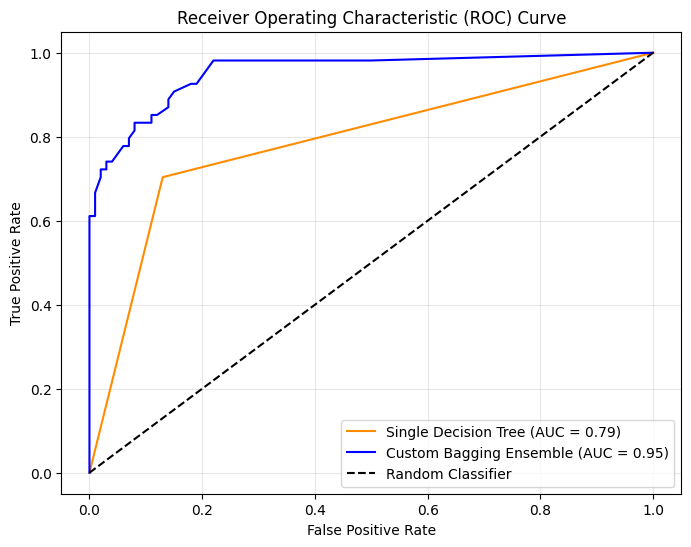


AUC for Single Decision Tree: 0.79
AUC for Custom Bagging Ensemble: 0.95


In [32]:
# Task 9: ROC-AUC Analysis and Curve Visualization

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calculate predicted class probabilities for the single decision tree
y_prob_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# 2. Calculate predicted class probabilities for the custom Bagging model
# Average the probabilities across all B decision trees
# Ensure predict_proba is called for each model and then averaged
all_ensemble_probs = np.array([model.predict_proba(X_test)[:, 1] for model in ensemble_models])
y_prob_bagging = np.mean(all_ensemble_probs, axis=0)

# Compute ROC curve and AUC for single tree
fpr_single, tpr_single, _ = roc_curve(y_test, y_prob_single_tree)
auc_single = roc_auc_score(y_test, y_prob_single_tree)

# Compute ROC curve and AUC for bagging ensemble
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
auc_bagging = roc_auc_score(y_test, y_prob_bagging)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.2f})', color='darkorange')
plt.plot(fpr_bagging, tpr_bagging, label=f'Custom Bagging Ensemble (AUC = {auc_bagging:.2f})', color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\nAUC for Single Decision Tree: {auc_single:.2f}")
print(f"AUC for Custom Bagging Ensemble: {auc_bagging:.2f}")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [34]:
# Task 10: Validation against Scikit-Learn's BaggingClassifier

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd # Already imported, but good practice to include if needed for new code

# 1. Instantiate Scikit-Learn's BaggingClassifier
sk_bagging_classifier = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None), # Use fully grown Decision Tree as base estimator
    n_estimators=50, # Number of base estimators (B=50 as in custom implementation)
    random_state=42, # For reproducibility
    bootstrap=True,  # Sampling with replacement (default, but explicit for clarity)
    n_jobs=-1        # Use all available CPU cores for parallel training
)

# 2. Fit the classifier on the training set
sk_bagging_classifier.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_sk_bagging = sk_bagging_classifier.predict(X_test)

# 4. Compare performance metrics
print("\n--- Scikit-Learn BaggingClassifier Performance ---")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sk_bagging))
print("Accuracy:", accuracy_score(y_test, y_pred_sk_bagging))
print("Precision:", precision_score(y_test, y_pred_sk_bagging))
print("Recall:", recall_score(y_test, y_pred_sk_bagging))
print("F1-Score:", f1_score(y_test, y_pred_sk_bagging))

print("\n--- Comparison with Custom Bagging Ensemble (from Task 8) ---")
# These variables (y_pred_bagging, y_test) are available from previous execution of Task 8
print("Custom Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Custom Bagging Precision:", precision_score(y_test, y_pred_bagging))
print("Custom Bagging Recall:", recall_score(y_test, y_pred_bagging))
print("Custom Bagging F1-Score:", f1_score(y_test, y_pred_bagging))


--- Scikit-Learn BaggingClassifier Performance ---
Confusion Matrix:
 [[91  9]
 [ 9 45]]
Accuracy: 0.8831168831168831
Precision: 0.8333333333333334
Recall: 0.8333333333333334
F1-Score: 0.8333333333333334

--- Comparison with Custom Bagging Ensemble (from Task 8) ---
Custom Bagging Accuracy: 0.8831168831168831
Custom Bagging Precision: 0.86
Custom Bagging Recall: 0.7962962962962963
Custom Bagging F1-Score: 0.8269230769230769


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?